# Basic GOAD Usage

This notebook demonstrates how to further customise a multiproblem.


### 1. Imports


In [1]:
# Import modules
import goad_py as goad
import numpy as np
import matplotlib.pyplot as plt
import os

# Some jargon to get access to the example geometries
current_dir = os.path.dirname(os.path.abspath(os.getcwd()))
geom_path = os.path.join(current_dir, "..", "examples", "data", "hex.obj")
geom_path = os.path.abspath(geom_path)

print(f"Geometry file: {geom_path}")

Geometry file: /Users/ixguard/Documents/work/rust/goad/examples/data/hex.obj


In [2]:
# Create an interval binning scheme for more precise resolution
# This reads as:
# Theta from 0 to 10 in steps of 0.5, then to 30 in steps of 1, then to 180 in steps of 5 degrees
# Phi from 0 to 360 in steps of 5 degrees
interval_binning = goad.BinningScheme.interval(
    thetas=[0, 10, 30, 180],
    theta_spacings=[0.1, 1, 1],
    phis=[0, 360],
    phi_spacings=[5],
)

# Create a discrete orientation scheme with specific Euler angles
# This defines a set of orientations that the simulation will average over
# Here, we define two orientations using Euler angles in degrees
# The default Euler angle rotation convention is ZYZ
# For a list of available conventions, see https://docs.rs/goad/0.1.0/goad/orientation/enum.EulerConvention.html
discrete_orientation = goad.create_discrete_orientation(
    [
        goad.Euler(20, 30, 40),  # Euler angles in degrees
        goad.Euler(50, 60, 70),  # Another orientation
    ],
    euler_convention=goad.EulerConvention.XYZ,  # Specify the rotation convention
)

# Create settings
settings = goad.Settings(
    geom_path=geom_path,
    wavelength=0.532,  # wavelength in particle units
    particle_refr_index_re=1.31,  # refr. index real part
    particle_refr_index_im=0.0,  # refr. index imaginary part
    medium_refr_index_re=1.0,  # surrounding medium refr. index real part
    medium_refr_index_im=0.0,  # surrounding medium refr. index imaginary part
    binning=interval_binning,  # use interval binning scheme
    orientation=discrete_orientation,  # discrete orientation scheme
    beam_power_threshold=0.005,  # power threshold before beam truncation
    cutoff=0.9999,  # total power cutoff before simulation ends
    max_rec=10,  # maximum number of beam recursions before truncation
    max_tir=10,  # maximum number of beam total internal reflections before truncation
)

In [3]:
# Create MultiProblem
multi_problem = goad.MultiProblem(settings)
print(f"Number of orientations: {multi_problem.num_orientations}")

# Solve the problem
multi_problem.py_solve()
print("Done.")

Number of orientations: 2
Done.


Integrated Scattering Parameters:
  Scattering cross-section: 228.235733
  Extinction cross-section: 228.235733
  Absorption cross-section: 0.000000
  Single scattering albedo: 1.000000
  Asymmetry parameter: 0.762550
Number of angular bins: 271
Angular range: 0.0° to 180.0°


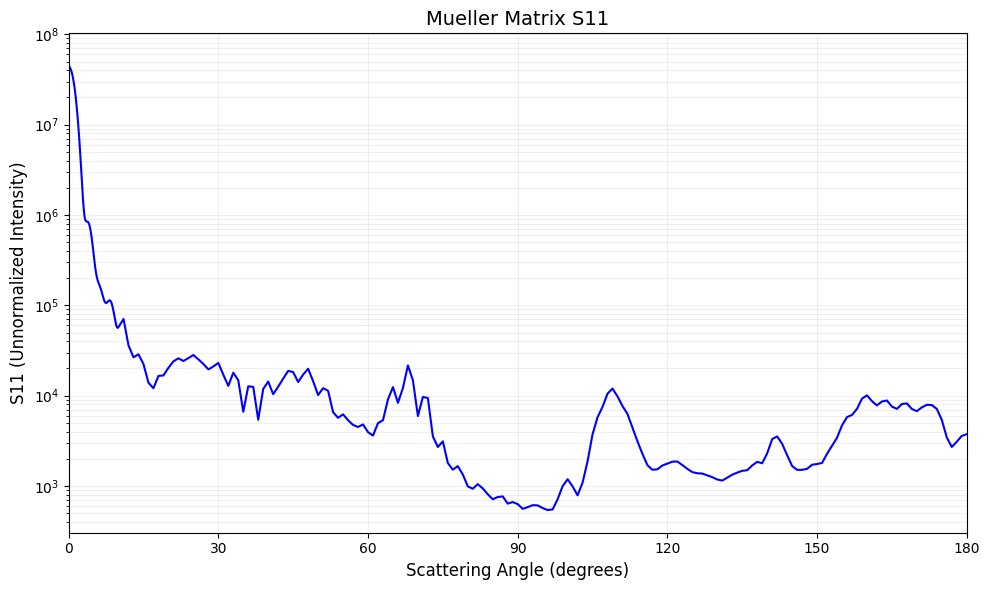

In [4]:
# Print results
results = multi_problem.results

print("Integrated Scattering Parameters:")
print(f"  Scattering cross-section: {results.scat_cross:.6f}")
print(f"  Extinction cross-section: {results.ext_cross:.6f}")
print(f"  Absorption cross-section: {results.ext_cross - results.scat_cross:.6f}")
print(f"  Single scattering albedo: {results.albedo:.6f}")
print(f"  Asymmetry parameter: {results.asymmetry:.6f}")

# Extract S11 element from 1D Mueller matrix
mueller_1d = results.mueller_1d
bins_1d = results.bins_1d

# S11 is the first element of the Mueller matrix
s11 = [row[0] for row in mueller_1d]  # Filter out zero or negative values for log scale
angles = bins_1d[: len(s11)]  # Match angles to filtered S11 values

print(f"Number of angular bins: {len(angles)}")
print(f"Angular range: {angles[0]:.1f}° to {angles[-1]:.1f}°")

# Plot S11 element
plt.figure(figsize=(10, 6))
plt.semilogy(angles, s11, "b-", linewidth=1.5)
plt.xlabel("Scattering Angle (degrees)", fontsize=12)
plt.ylabel("S11 (Unnormalized Intensity)", fontsize=12)
plt.title("Mueller Matrix S11", fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlim(0, 180)
plt.xticks(np.arange(0, 181, 30))

plt.tight_layout()
plt.show()

In [5]:
# Optional: Save results to a directory
# multi_problem.py_writeup()